In [20]:
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_gate_map, plot_error_map

from qiskit.circuit import Parameter

from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes import TrivialLayout, FullAncillaAllocation, EnlargeWithAncilla, ApplyLayout
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
%matplotlib inline
import numpy as np 
#connect to real backend
service = QiskitRuntimeService(
    channel="", 
    token="",
    instance="",
    name=""
)

real_backend = service.backend("ibm_boston")
noisy_sim = AerSimulator.from_backend(real_backend)
sim = AerSimulator()

target = real_backend.target

qiskit_runtime_service._discover_account:WARNING:2026-03-30 09:10:09,190: Loading account with name Research_CVUT-us. Any input 'channel', 'token' or 'url' are ignored.


Connected to: ibm_pittsburgh
Number of qubits: 156
Status: active


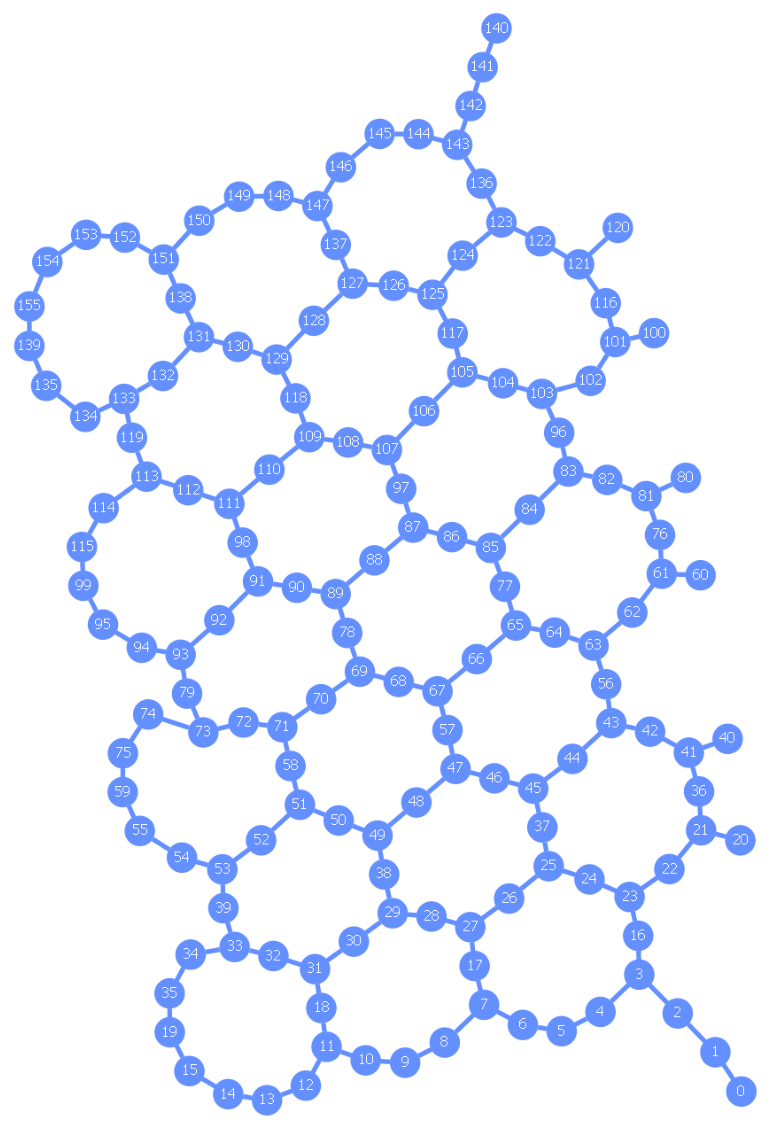

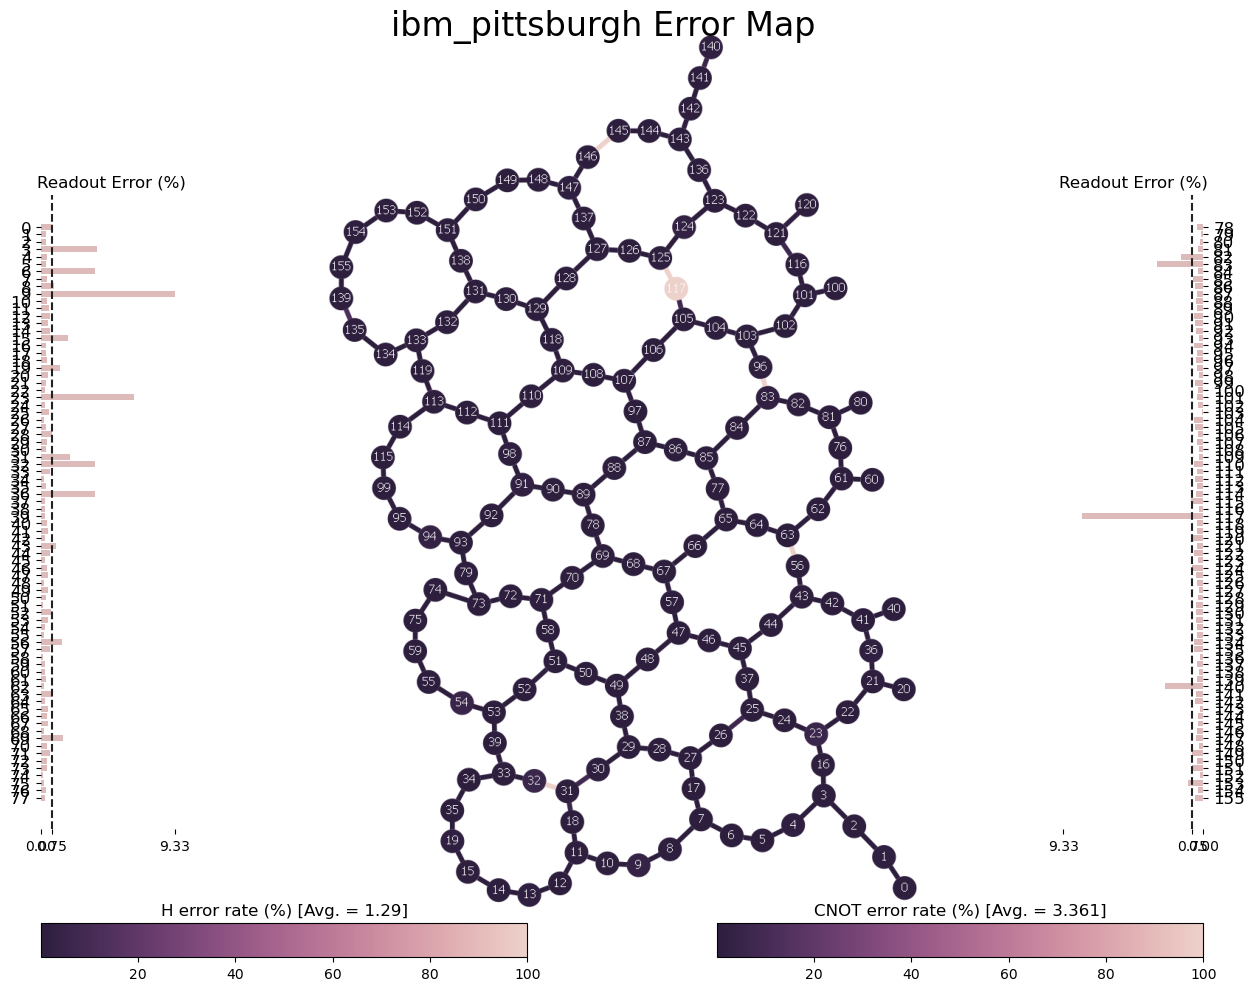

In [7]:
#print backend data
print(f"Connected to: {real_backend.name}")
print(f"Number of qubits: {real_backend.num_qubits}")
print(f"Status: {real_backend.status().status_msg}")
# Plot the physical connections (Topology)
plot_gate_map(real_backend)
plt.savefig("Topology_Pittsburgh")
plt.show()

# Plot a heat map of the gate errors across the whole chip
plot_error_map(real_backend)
plt.savefig("ErrmapPittsburgh.png")
plt.show()

In [17]:
N=8
#number of qubits
Ndata=[]
#number of distances
for i in range(1, N):
    Ndata.append(i)
Sdata=[]
#String for saving S values
q=QuantumRegister(8)
c=ClassicalRegister(2)
qc=QuantumCircuit(q,c)
#register definition
initial_layout = [92, 91,  90, 89, 78, 69, 68, 67]
#path definition
pm = generate_preset_pass_manager(
    backend=real_backend, 
    optimization_level=0, 
    initial_layout=initial_layout
)
transpiled_qc = pm.run(qc)
#chsh code
def chsh (qc, q0, q1, c0, c1):

    settings = [
        ("A0B0", [0, -np.pi/4] ),
        ("A0B1", [0, -3*np.pi/4] ),
        ("A1B0", [-np.pi/2, -np.pi/4] ),
        ("A1B1", [-np.pi/2, -3*np.pi/4] )
    ]
    #chsh measurment settings
    chsh_shots = 100000
    
    sim = AerSimulator(method="matrix_product_state") #methods of aersim
    noisy_sim = AerSimulator.from_backend(real_backend)

    q0_angle = Parameter('θ0')
    q1_angle = Parameter('θ2')
    
    qc2= qc.copy()
    qc2.ry(q0_angle, q0)
    qc2.ry(q1_angle, q1)
    qc2.measure(q0, c0)
    qc2.measure(q1, c1)
    #chsh circuit 
    transpiled_qc = pm.run(qc2)
        
    #sampler = Sampler(mode=sim)
    #sampler = Sampler(mode=noisy_sim)
    sampler = Sampler(mode=real_backend)

    pubs = []
    for st in settings:
        pubs.append( (transpiled_qc, st[1], chsh_shots))
    
    job = sampler.run( pubs )
    print("Job ID: " + job.job_id())
    print("Status: "+ job.status())
    result = job.result()
    #job data
    results_E=[]

    for sindex in range(len(settings)):
        counts = result[sindex].join_data().get_counts()
        s00 = counts.get('00', 0)
        s11 = counts.get('11', 0)
        e01 = counts.get('01', 0)
        e10 = counts.get('10', 0)

        total = s00 + s11 + e01 + e10
        E = (s00 + s11 - e01 - e10) / total if total > 0 else 0
        results_E.append(E)
        print(E)

    #S value calculation and saving
    S = results_E[0] - results_E[1] + results_E[2] + results_E[3]
    Sdata.append(S)
    print("S: "+str(S))

In [18]:
#chsh test for given qubit with distance n
def RunCircuit(n):#
    qc1=qc.copy()
#-----------------------------------------------------------------------------
    qc1.h(q[0])
    qc1.cx(q[0], q[1])
    for j in range(1, n):
        qc1.swap(q[j], q[j+1])
    chsh(qc1, q[0], q[n], c[0], c[1])
#----------------------------------------------------------------------------------------
    print("Number ", n, " finished")

In [19]:
#confirm that the code has been started
print("Cominciato")
for i in range (0, 1):#RunCount Setting1
    Sdata=[]
    for m in range(N-1, N):#RunCount Setting2 - set distances to collect data from
        RunCircuit(m)
    #plot graph based on collected data  
    plt.plot(Ndata, Sdata, marker="o")
    plt.title("Hodnota S na základě vzdálenosti qubitů, IBM Pittsburgh")
    plt.axhline(y=2, color="red", linestyle="--")
    plt.ylabel("Hodnota S")
    plt.xlabel("Vzdálenost qubitů")
    plt.xticks(np.arange(0, N, 1.0))
    plt.yticks(np.arange(0, 2*np.sqrt(2), 0.4))
    plt.savefig("Schart"+str(i))
    plt.show()
print("Data: ", Sdata)

Cominciato
Job ID: d750ljoqhmps73b4lmkg
Status: QUEUED
0.44226
-0.65338
0.62372
0.42996
S: 2.14932
Number  7  finished


ValueError: x and y must have same first dimension, but have shapes (7,) and (1,)

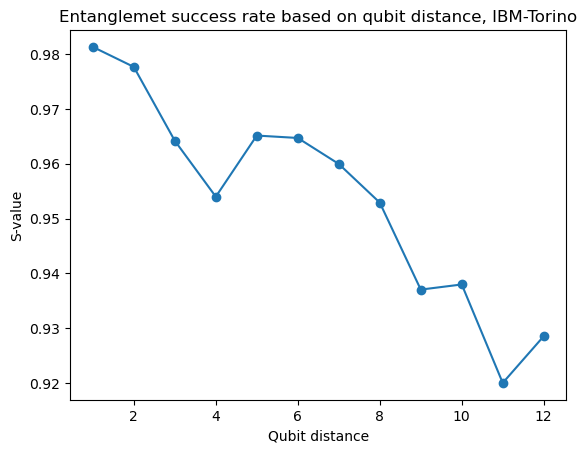

In [45]:
plt.plot(Ndata, Sdata, marker="o")
plt.title("Entanglemet success rate based on qubit distance, IBM-Marrakesh")
plt.ylabel("S-value")
plt.xlabel("Qubit distance")
plt.savefig("Schart1.png")
plt.show()

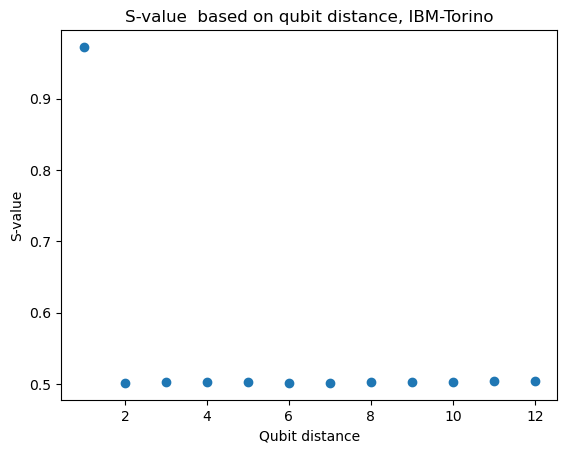

In [17]:
plt.scatter(Ndata, Sdata)
plt.title("S-value  based on qubit distance, IBM-Torino")
plt.ylabel("S-value")
plt.xlabel("Qubit distance")
plt.savefig("Schart2.png")
plt.show()

In [28]:
import os
print(os.getcwd())

C:\Users\erikm


In [4]:
N=13
Ndata=[]
for i in range(1, N):
    Ndata.append(i)
Sdata=[]
initial_layout=[2, 3, 4, 5, 6, 7, 17, 27, 26, 25, 24, 23, 16]#---------------------------------------
q = QuantumRegister(N)
c = ClassicalRegister(2)
qc = QuantumCircuit(q, c)
pm = generate_preset_pass_manager(
backend=real_backend, 
optimization_level=0, 
initial_layout=initial_layout)
transpiled_qc = pm.run(qc)